<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/Transmon_Family_Tree_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

In [1]:
!uv pip install --system -q graphviz

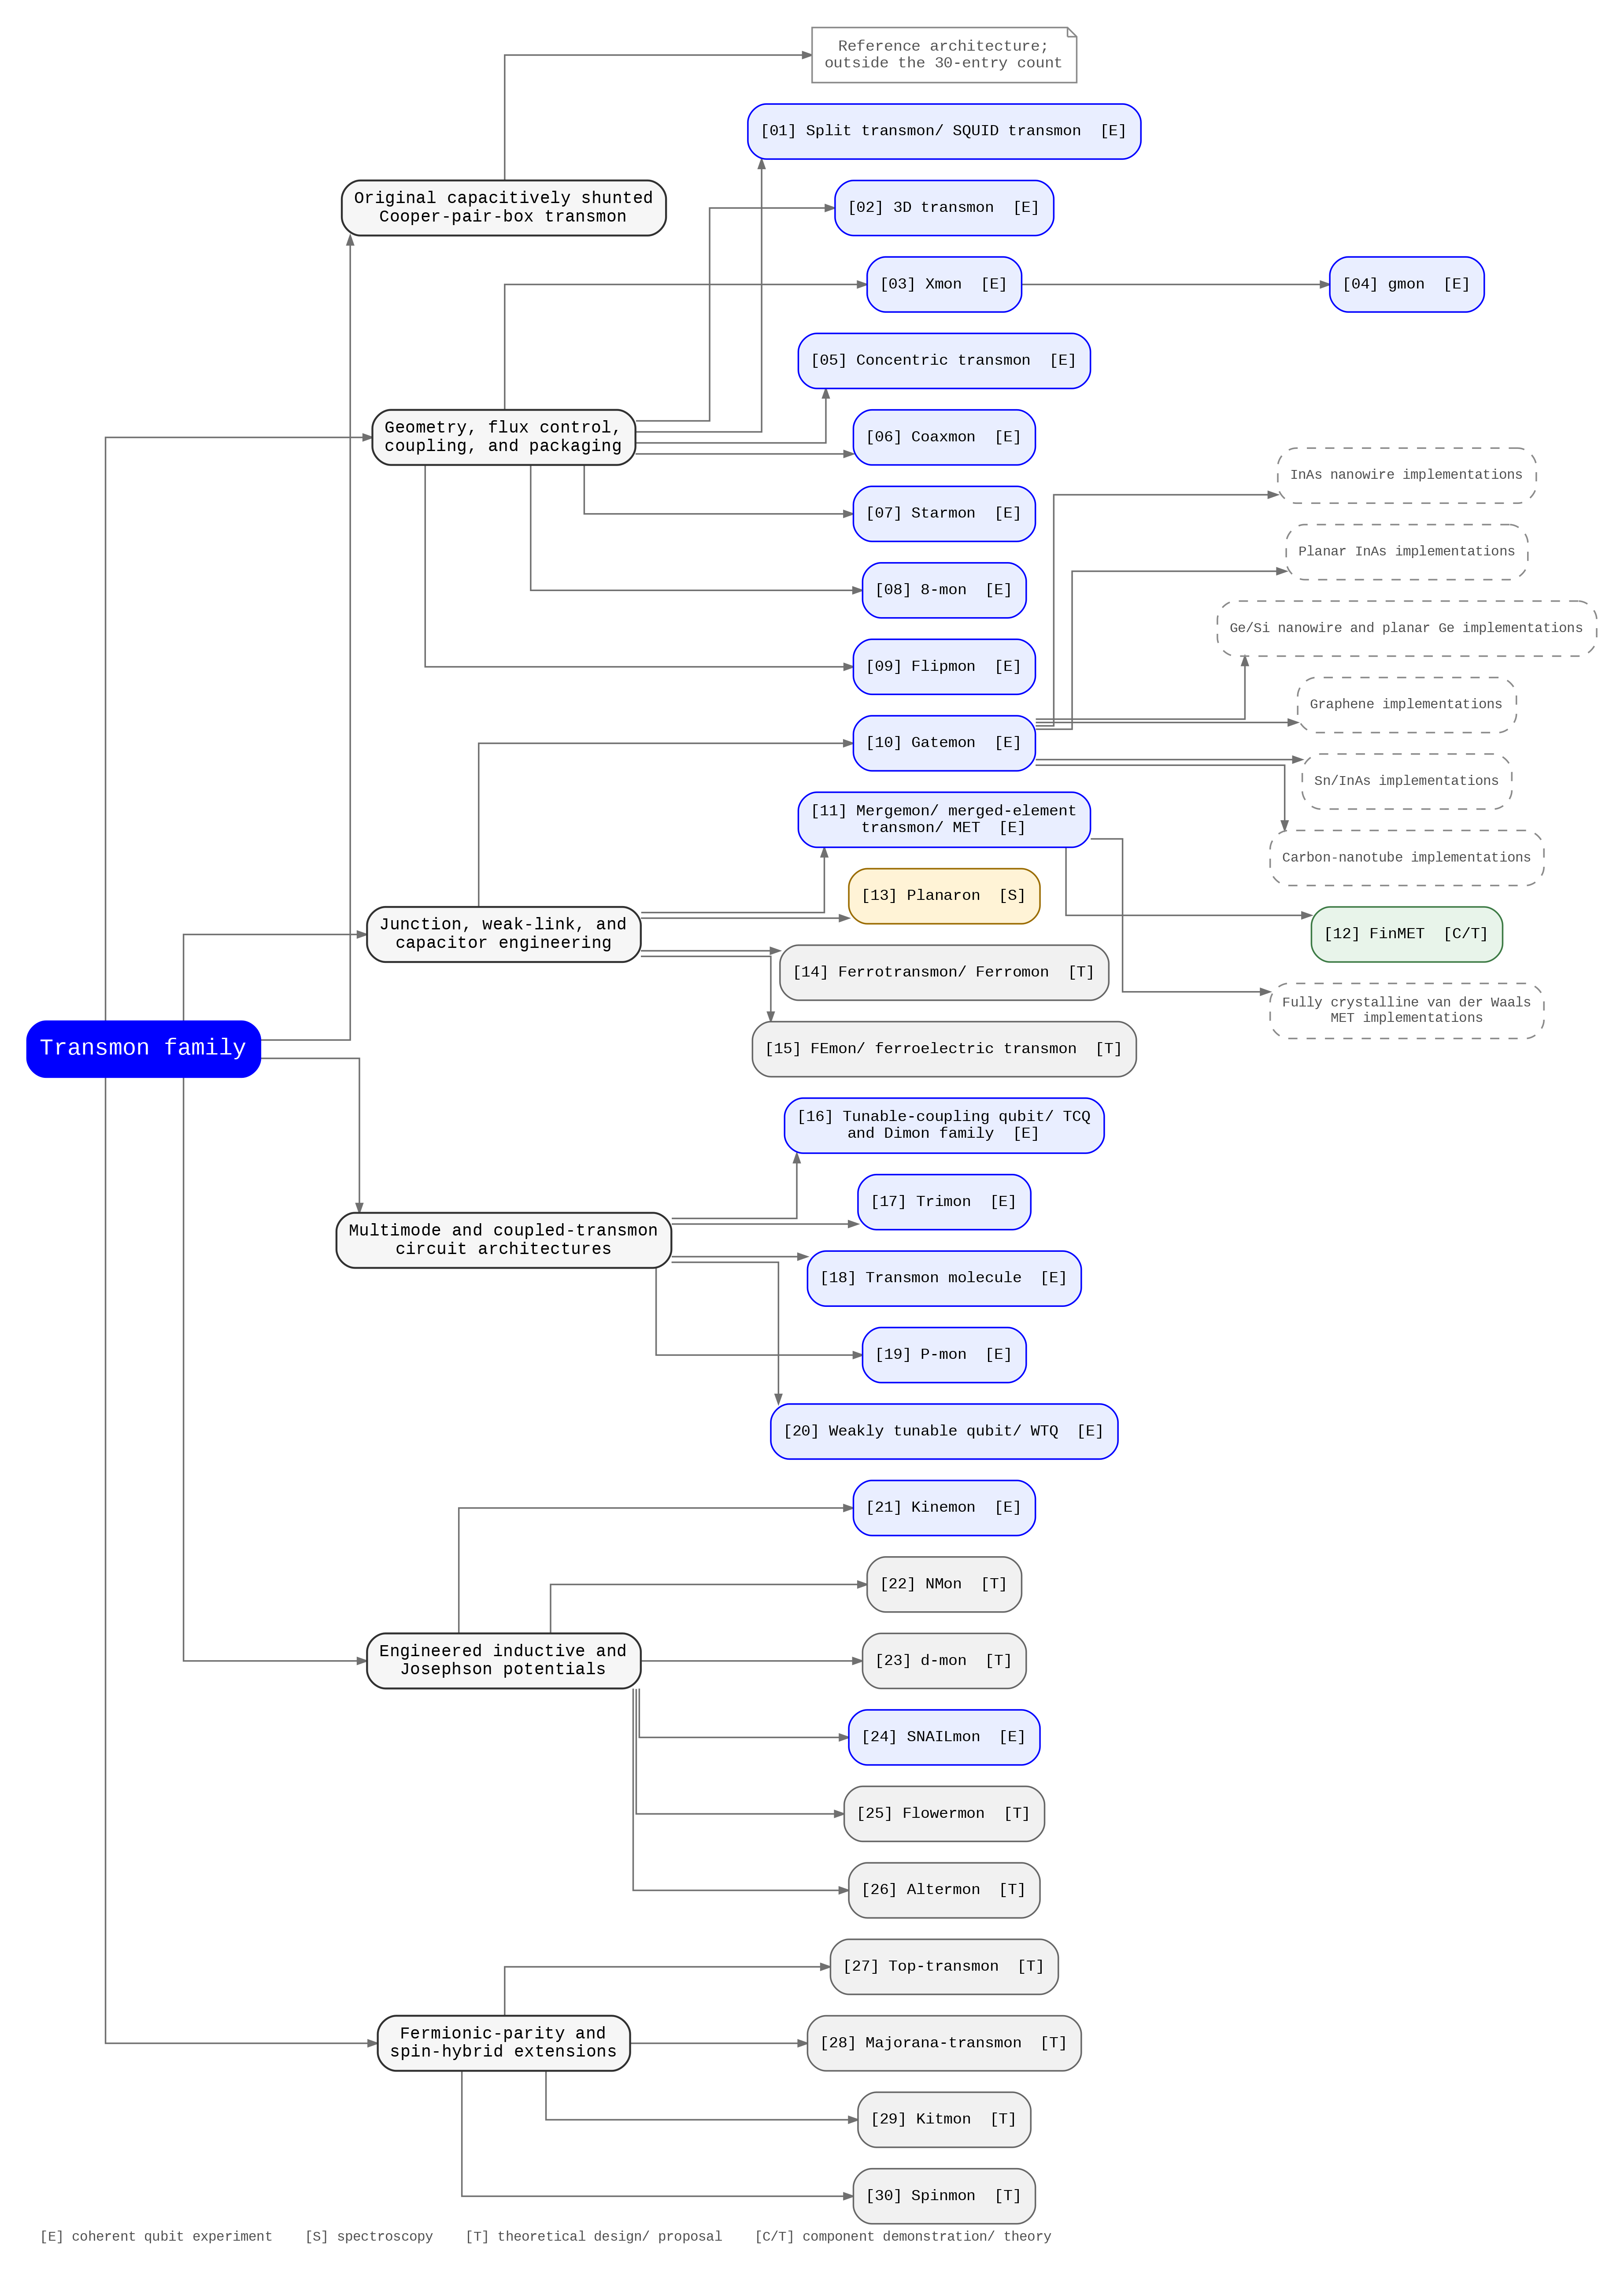

Transmon-family Graphviz render
Layout engine       : dot
Rank direction      : LR
PNG resolution      : 250 DPI
Output file         : /content/transmon_family_tree.png
PNG size            : 593.5 KiB
Numbered entries    : 30
Gatemon subbranches : True
MET subbranches     : True


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [3]:
"""Render the published transmon-family taxonomy as a Graphviz tree."""

from dataclasses import dataclass
from pathlib import Path

from graphviz import Digraph
from IPython.display import Image, display

try:
    from google.colab import files
except ImportError:
    files = None


# =============================================================================
# - Control knobs
# =============================================================================

OUTPUT_FILENAME = "transmon_family_tree.png"

# Graphviz layout engine. "dot" is appropriate for hierarchical trees.
GRAPHVIZ_ENGINE = "dot"

# Use "LR" for left-to-right or "TB" for top-to-bottom.
RANK_DIRECTION = "LR"

# PNG rendering resolution.
GRAPH_DPI = 250

# Typography.
FONT_NAME = "DejaVu Sans"
NODE_FONT_SIZE_PT = 10
CATEGORY_FONT_SIZE_PT = 11
ROOT_FONT_SIZE_PT = 15
IMPLEMENTATION_FONT_SIZE_PT = 9

# Tree geometry.
NODE_SEPARATION_IN = 0.20
RANK_SEPARATION_IN = 0.70
GRAPH_PADDING_IN = 0.25

# Optional hierarchy branches.
SHOW_GATEMON_IMPLEMENTATIONS = True
SHOW_MET_IMPLEMENTATIONS = True

# Automatically open the browser download dialog after rendering.
AUTO_DOWNLOAD_PNG = True

# Main root and experimental-status colors.
ROOT_COLOR = "#0000FF"
ROOT_FONT_COLOR = "#FFFFFF"

# Publication/ demonstration status styles.
STATUS_STYLES = {
    "E": {
        "fillcolor": "#E9EEFF",
        "color": "#0000FF",
    },
    "S": {
        "fillcolor": "#FFF3D6",
        "color": "#9A6B00",
    },
    "T": {
        "fillcolor": "#F1F1F1",
        "color": "#666666",
    },
    "C/T": {
        "fillcolor": "#E8F4EA",
        "color": "#3C7A44",
    },
}


# =============================================================================
# - Data structures
# =============================================================================


@dataclass(frozen=True)
class TreeNode:
    """Describes one status-bearing node in the transmon tree.

    Attributes:
        node_id: Unique Graphviz identifier.
        parent_id: Graphviz identifier of the parent node.
        label: Human-readable node label.
        status: Publication or demonstration status code.
    """

    node_id: str
    parent_id: str
    label: str
    status: str


@dataclass(frozen=True)
class ImplementationNode:
    """Describes an implementation branch without a separate status code.

    Attributes:
        node_id: Unique Graphviz identifier.
        parent_id: Graphviz identifier of the parent node.
        label: Human-readable implementation label.
    """

    node_id: str
    parent_id: str
    label: str


# =============================================================================
# - Tree content
# =============================================================================

CATEGORY_NODES = (
    (
        "reference",
        "Original capacitively shunted\n"
        "Cooper-pair-box transmon",
    ),
    (
        "geometry",
        "Geometry, flux control,\n"
        "coupling, and packaging",
    ),
    (
        "junction",
        "Junction, weak-link, and\n"
        "capacitor engineering",
    ),
    (
        "multimode",
        "Multimode and coupled-transmon\n"
        "circuit architectures",
    ),
    (
        "potential",
        "Engineered inductive and\n"
        "Josephson potentials",
    ),
    (
        "hybrid",
        "Fermionic-parity and\n"
        "spin-hybrid extensions",
    ),
)


TRANSMON_NODES = (
    # Geometry, flux control, coupling, and packaging.
    TreeNode(
        "01",
        "geometry",
        "[01] Split transmon/ SQUID transmon",
        "E",
    ),
    TreeNode(
        "02",
        "geometry",
        "[02] 3D transmon",
        "E",
    ),
    TreeNode(
        "03",
        "geometry",
        "[03] Xmon",
        "E",
    ),
    TreeNode(
        "04",
        "03",
        "[04] gmon",
        "E",
    ),
    TreeNode(
        "05",
        "geometry",
        "[05] Concentric transmon",
        "E",
    ),
    TreeNode(
        "06",
        "geometry",
        "[06] Coaxmon",
        "E",
    ),
    TreeNode(
        "07",
        "geometry",
        "[07] Starmon",
        "E",
    ),
    TreeNode(
        "08",
        "geometry",
        "[08] 8-mon",
        "E",
    ),
    TreeNode(
        "09",
        "geometry",
        "[09] Flipmon",
        "E",
    ),

    # Junction, weak-link, and capacitor engineering.
    TreeNode(
        "10",
        "junction",
        "[10] Gatemon",
        "E",
    ),
    TreeNode(
        "11",
        "junction",
        "[11] Mergemon/ merged-element\n"
        "transmon/ MET",
        "E",
    ),
    TreeNode(
        "12",
        "11",
        "[12] FinMET",
        "C/T",
    ),
    TreeNode(
        "13",
        "junction",
        "[13] Planaron",
        "S",
    ),
    TreeNode(
        "14",
        "junction",
        "[14] Ferrotransmon/ Ferromon",
        "T",
    ),
    TreeNode(
        "15",
        "junction",
        "[15] FEmon/ ferroelectric transmon",
        "T",
    ),

    # Multimode and coupled-transmon circuit architectures.
    TreeNode(
        "16",
        "multimode",
        "[16] Tunable-coupling qubit/ TCQ\n"
        "and Dimon family",
        "E",
    ),
    TreeNode(
        "17",
        "multimode",
        "[17] Trimon",
        "E",
    ),
    TreeNode(
        "18",
        "multimode",
        "[18] Transmon molecule",
        "E",
    ),
    TreeNode(
        "19",
        "multimode",
        "[19] P-mon",
        "E",
    ),
    TreeNode(
        "20",
        "multimode",
        "[20] Weakly tunable qubit/ WTQ",
        "E",
    ),

    # Engineered inductive and Josephson potentials.
    TreeNode(
        "21",
        "potential",
        "[21] Kinemon",
        "E",
    ),
    TreeNode(
        "22",
        "potential",
        "[22] NMon",
        "T",
    ),
    TreeNode(
        "23",
        "potential",
        "[23] d-mon",
        "T",
    ),
    TreeNode(
        "24",
        "potential",
        "[24] SNAILmon",
        "E",
    ),
    TreeNode(
        "25",
        "potential",
        "[25] Flowermon",
        "T",
    ),
    TreeNode(
        "26",
        "potential",
        "[26] Altermon",
        "T",
    ),

    # Fermionic-parity and spin-hybrid extensions.
    TreeNode(
        "27",
        "hybrid",
        "[27] Top-transmon",
        "T",
    ),
    TreeNode(
        "28",
        "hybrid",
        "[28] Majorana-transmon",
        "T",
    ),
    TreeNode(
        "29",
        "hybrid",
        "[29] Kitmon",
        "T",
    ),
    TreeNode(
        "30",
        "hybrid",
        "[30] Spinmon",
        "T",
    ),
)


GATEMON_IMPLEMENTATIONS = (
    ImplementationNode(
        "10a",
        "10",
        "InAs nanowire implementations",
    ),
    ImplementationNode(
        "10b",
        "10",
        "Planar InAs implementations",
    ),
    ImplementationNode(
        "10c",
        "10",
        "Ge/Si nanowire and planar Ge implementations",
    ),
    ImplementationNode(
        "10d",
        "10",
        "Graphene implementations",
    ),
    ImplementationNode(
        "10e",
        "10",
        "Sn/InAs implementations",
    ),
    ImplementationNode(
        "10f",
        "10",
        "Carbon-nanotube implementations",
    ),
)


MET_IMPLEMENTATIONS = (
    ImplementationNode(
        "11a",
        "11",
        "Fully crystalline van der Waals\n"
        "MET implementations",
    ),
)


# =============================================================================
# - Graph construction
# =============================================================================


def configure_graph() -> Digraph:
    """Creates and configures the Graphviz directed graph.

    Returns:
        Configured Graphviz Digraph instance.
    """
    graph = Digraph(
        name="transmon_family_tree",
        engine=GRAPHVIZ_ENGINE,
    )

    graph.attr(
        rankdir=RANK_DIRECTION,
        dpi=str(GRAPH_DPI),
        bgcolor="white",
        pad=str(GRAPH_PADDING_IN),
        nodesep=str(NODE_SEPARATION_IN),
        ranksep=str(RANK_SEPARATION_IN),
        splines="ortho",
        outputorder="edgesfirst",
        ordering="out",
        newrank="true",
        labelloc="b",
        labeljust="l",
        label=(
            "[E] coherent qubit experiment    "
            "[S] spectroscopy    "
            "[T] theoretical design/ proposal    "
            "[C/T] component demonstration/ theory"
        ),
        fontname=FONT_NAME,
        fontsize="9",
        fontcolor="#505050",
    )

    graph.attr(
        "node",
        shape="box",
        style="rounded,filled",
        fontname=FONT_NAME,
        fontsize=str(NODE_FONT_SIZE_PT),
        margin="0.11,0.07",
        color="#4A4A4A",
        fillcolor="white",
        penwidth="1.0",
    )

    graph.attr(
        "edge",
        color="#707070",
        penwidth="1.0",
        arrowsize="0.60",
    )

    return graph


def add_root_node(graph: Digraph) -> None:
    """Adds the root node to the transmon-family tree.

    Args:
        graph: Graphviz graph receiving the node.
    """
    graph.node(
        "root",
        "Transmon family",
        shape="box",
        style="rounded,filled,bold",
        fillcolor=ROOT_COLOR,
        color=ROOT_COLOR,
        fontcolor=ROOT_FONT_COLOR,
        fontsize=str(ROOT_FONT_SIZE_PT),
        penwidth="1.6",
    )


def add_category_nodes(graph: Digraph) -> None:
    """Adds the major first-level transmon categories.

    Args:
        graph: Graphviz graph receiving the category nodes.
    """
    for node_id, label in CATEGORY_NODES:
        graph.node(
            node_id,
            label,
            shape="box",
            style="rounded,filled,bold",
            fillcolor="#F6F6F6",
            color="#303030",
            penwidth="1.25",
            fontsize=str(CATEGORY_FONT_SIZE_PT),
        )
        graph.edge("root", node_id)

    graph.node(
        "reference_note",
        "Reference architecture;\n"
        "outside the 30-entry count",
        shape="note",
        style="filled",
        fillcolor="#FFFFFF",
        color="#8A8A8A",
        fontcolor="#555555",
    )
    graph.edge("reference", "reference_note")


def add_transmon_nodes(graph: Digraph) -> None:
    """Adds the 30 numbered transmon-family entries.

    Args:
        graph: Graphviz graph receiving the transmon nodes.

    Raises:
        ValueError: If a node contains an unknown status code.
    """
    for node in TRANSMON_NODES:
        if node.status not in STATUS_STYLES:
            raise ValueError(
                f"Unknown status code for {node.node_id}: "
                f"{node.status}"
            )

        style = STATUS_STYLES[node.status]

        graph.node(
            node.node_id,
            f"{node.label}  [{node.status}]",
            fillcolor=style["fillcolor"],
            color=style["color"],
        )
        graph.edge(node.parent_id, node.node_id)


def add_implementation_node(
    graph: Digraph,
    node: ImplementationNode,
) -> None:
    """Adds a dashed implementation-level node.

    Args:
        graph: Graphviz graph receiving the implementation node.
        node: Implementation node specification.
    """
    graph.node(
        node.node_id,
        node.label,
        shape="box",
        style="rounded,dashed",
        fillcolor="white",
        color="#8A8A8A",
        fontcolor="#505050",
        fontsize=str(IMPLEMENTATION_FONT_SIZE_PT),
    )
    graph.edge(node.parent_id, node.node_id)


def add_implementation_branches(graph: Digraph) -> None:
    """Adds material and fabrication implementation subbranches.

    Args:
        graph: Graphviz graph receiving implementation nodes.
    """
    if SHOW_GATEMON_IMPLEMENTATIONS:
        for node in GATEMON_IMPLEMENTATIONS:
            add_implementation_node(graph, node)

    if SHOW_MET_IMPLEMENTATIONS:
        for node in MET_IMPLEMENTATIONS:
            add_implementation_node(graph, node)


def build_transmon_tree() -> Digraph:
    """Builds the complete transmon-family taxonomy.

    Returns:
        Fully populated Graphviz Digraph.
    """
    graph = configure_graph()

    add_root_node(graph)
    add_category_nodes(graph)
    add_transmon_nodes(graph)
    add_implementation_branches(graph)

    return graph


# =============================================================================
# - PNG rendering and notebook display
# =============================================================================


def render_png_in_memory(
    graph: Digraph,
    output_path: Path,
) -> bytes:
    """Renders a Graphviz graph directly into PNG bytes.

    The Graphviz ``pipe`` interface keeps the initial rendered image in
    memory. The exact byte sequence is then written to disk so the displayed
    image and downloaded PNG are identical.

    Args:
        graph: Graphviz graph to render.
        output_path: Filesystem destination for the PNG.

    Returns:
        Rendered PNG byte sequence.
    """
    png_bytes = graph.pipe(format="png")

    output_path.write_bytes(png_bytes)

    return png_bytes


def display_png(png_bytes: bytes) -> None:
    """Displays PNG bytes directly inside the notebook.

    Args:
        png_bytes: In-memory PNG byte sequence.
    """
    display(Image(data=png_bytes))


def download_png(output_path: Path) -> None:
    """Triggers a browser download in Google Colab.

    Args:
        output_path: PNG path to download.
    """
    if files is None:
        print(
            "Google Colab download API unavailable. "
            f"PNG remains at: {output_path}"
        )
        return

    files.download(str(output_path))


def main() -> None:
    """Builds, renders, displays, and optionally downloads the tree."""
    output_path = Path(OUTPUT_FILENAME)

    graph = build_transmon_tree()

    # Render once so display and downloaded output use identical PNG bytes.
    png_bytes = render_png_in_memory(
        graph=graph,
        output_path=output_path,
    )

    display_png(png_bytes)

    print("=" * 72)
    print("Transmon-family Graphviz render")
    print("=" * 72)
    print(f"Layout engine       : {GRAPHVIZ_ENGINE}")
    print(f"Rank direction      : {RANK_DIRECTION}")
    print(f"PNG resolution      : {GRAPH_DPI} DPI")
    print(f"Output file         : {output_path.resolve()}")
    print(f"PNG size            : {len(png_bytes)/ 1024:.1f} KiB")
    print(f"Numbered entries    : {len(TRANSMON_NODES)}")
    print(
        "Gatemon subbranches : "
        f"{SHOW_GATEMON_IMPLEMENTATIONS}"
    )
    print(
        "MET subbranches     : "
        f"{SHOW_MET_IMPLEMENTATIONS}"
    )
    print("=" * 72)

    if AUTO_DOWNLOAD_PNG:
        download_png(output_path)

if __name__ == "__main__":
    main()